In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np 

In [3]:
# load data
df = pd.read_csv("Data/Epi_Task_Data.csv")

# compute mean ILI% per county per year
mean_ili = (df.groupby(["county", "year"], as_index=False)["ili_percentage"]
              .mean()
              .rename(columns={"ili_percentage": "mean_ili"}))

print(mean_ili.head())


     county  year  mean_ili
0  Kakamega  2023     4.060
1  Kakamega  2024     4.540
2    Kiambu  2023     3.895
3    Kiambu  2024     3.705
4    Kisumu  2023     4.065


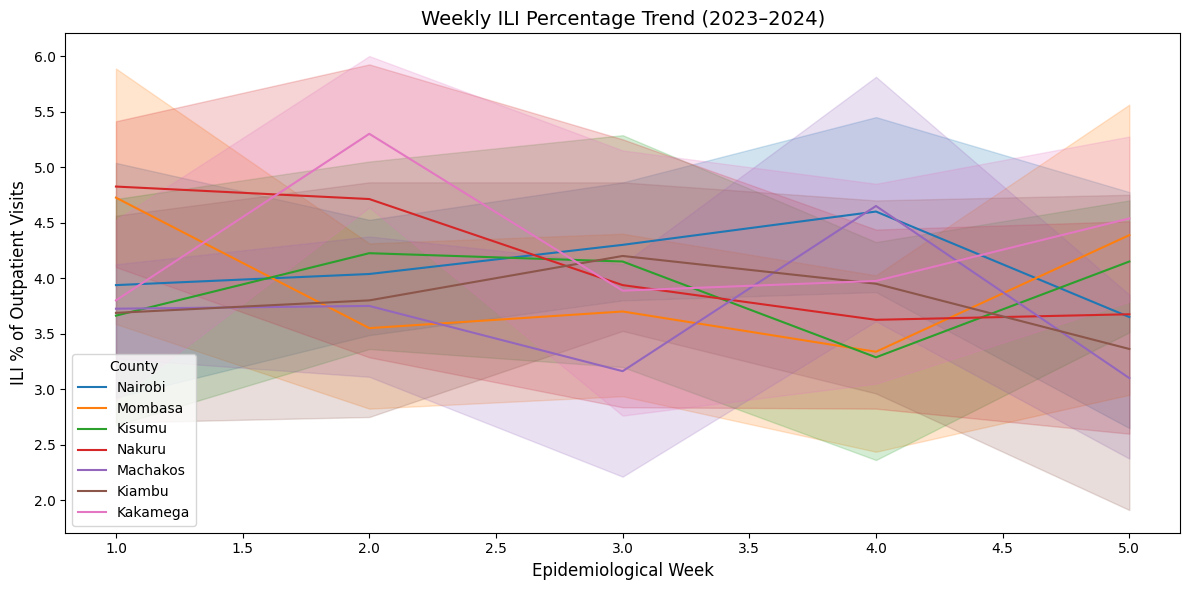

In [5]:
fig, ax = plt.subplots(figsize=(12,6))

sns.lineplot(data=df, x="epi_week", y="ili_percentage", hue="county", ax=ax)

ax.set_title("Weekly ILI Percentage Trend (2023–2024)", fontsize=14)
ax.set_xlabel("Epidemiological Week", fontsize=12)
ax.set_ylabel("ILI % of Outpatient Visits", fontsize=12)
ax.legend(title="County")

plt.tight_layout()


In [7]:
# estimate ILI cases
df["ili_cases"] = (df["ili_percentage"]/100) * df["population"]

# aggregate
ili_cases = df.groupby("county", as_index=False)["ili_cases"].sum()
pop = df.groupby("county", as_index=False)["population"].mean()

# merge
incidence = ili_cases.merge(pop, on="county")
incidence["incidence_rate"] = (incidence["ili_cases"] / incidence["population"]) * 100000

# select 3 counties
subset = incidence[incidence["county"].isin(["Nairobi", "Kisumu", "Mombasa"])]
print(subset)


    county  ili_cases  population  incidence_rate
2   Kisumu   7573.153    4917.875   153992.384922
4  Mombasa   8983.599    5581.850   160943.038598
5  Nairobi   6813.832    4119.350   165410.368141


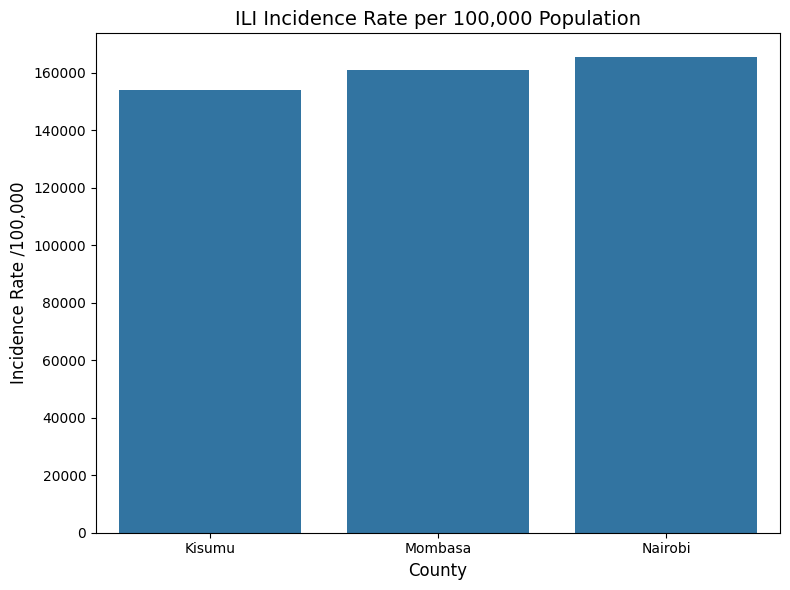

In [8]:
fig, ax = plt.subplots(figsize=(8,6))

sns.barplot(data=subset, x="county", y="incidence_rate", ax=ax)

ax.set_title("ILI Incidence Rate per 100,000 Population", fontsize=14)
ax.set_xlabel("County", fontsize=12)
ax.set_ylabel("Incidence Rate /100,000", fontsize=12)

plt.tight_layout()

In [9]:
from scipy.stats import f_oneway, kruskal

nairobi = df[df["county"]=="Nairobi"]["ili_percentage"]
kisumu = df[df["county"]=="Kisumu"]["ili_percentage"]
mombasa = df[df["county"]=="Mombasa"]["ili_percentage"]

anova_res = f_oneway(nairobi, kisumu, mombasa)
kruskal_res = kruskal(nairobi, kisumu, mombasa)

print("ANOVA:", anova_res)
print("Kruskal-Wallis:", kruskal_res)


ModuleNotFoundError: No module named 'scipy'